# Real Life Machine Learning - Group 16, Salwa and Sude


#### Predicting Under-five Mortality Rates for a better Vaccination Distribution

## Part 1: Introduction - Motivation and Problem Statement

In the global health scene, particularly vaccination and immunization, resources are scarce, thus, it is crucial to optimize vaccine distribution. According to Chi &Bump (2018) in their paper of resource allocation processes, most international institution determine eligibility by apply a combination of epidemiological thresholds, income-level criteria and health system capacity. 
Allocation amounts are then calculated using burden of disease models, in addition to other metrics and indicators. Furthermore, allocation is often determined few years in advance, meaning organizations need to forecast whether a country meets the eligibility criteria. A robust predicative machine learning model that can proactively identify high-risk countries, optimize vaccine distribution, justify donor funding is of need. 
Machine learning offers a practical, data-driven solution that supports decision-making. 

## Part 2: Suggested Methodology - Data Understanding and Exploratory Data Analysis (EDA)

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV



Firstly, we need to load the data set and look at the basic information to get a better understanding of the data itself. 

In [106]:
life_data = pd.read_csv ('Life Expectancy Data v2.csv')

In [107]:
life_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy (men)            2938 non-null   int64  
 4   Life expectancy(women)           2938 non-null   int64  
 5   Adult Mortality (men)            2938 non-null   int64  
 6   Adult Mortality (women)          2938 non-null   int64  
 7   Infant deaths                    2938 non-null   int64  
 8   Alcohol                          2744 non-null   float64
 9   Percentage expenditure           2938 non-null   float64
 10  Hepatitis B(men)                 2938 non-null   int64  
 11  Hepatitis B(women)               2938 non-null   int64  
 12  Measles             

In [108]:
life_data.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy (men)                0
Life expectancy(women)               0
Adult Mortality (men)                0
Adult Mortality (women)              0
Infant deaths                        0
Alcohol                            194
Percentage expenditure               0
Hepatitis B(men)                     0
Hepatitis B(women)                   0
Measles                              0
BMI                                 34
Under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

We observed quite some missing values, we are going to keep those in mind and impute it explicitly. 
- Missing values in features like GDP show us that there are some human errors in this data set. (every country has a GDP so 0 as a value is not realistic)

In [109]:
life_data.shape

(2938, 25)

In [110]:
life_data.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy (men)                int64
Life expectancy(women)               int64
Adult Mortality (men)                int64
Adult Mortality (women)              int64
Infant deaths                        int64
Alcohol                            float64
Percentage expenditure             float64
Hepatitis B(men)                     int64
Hepatitis B(women)                   int64
Measles                              int64
BMI                                float64
Under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income comp

In [111]:
pd.set_option('display.float_format', '{:.2f}'.format)
life_data.describe()

,Year,Life expectancy (men),Life expectancy(women),Adult Mortality (men),Adult Mortality (women),Infant deaths,Alcohol,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2938.00,2938.00,2938.00,2938.00,2938.00,2744.00,2938.00,2938.00,2938.00,...,2919.00,2712.00,2919.00,2938.00,2490.00,2286.00,2904.00,2904.00,2771.00,2775.00
mean,2007.52,67.71,67.63,74.73,74.56,30.30,4.60,738.25,46.01,46.47,...,82.55,5.94,82.32,1.74,7483.16,12753375.12,4.84,4.87,0.63,11.99
std,4.61,10.35,10.33,14.73,14.68,117.93,4.05,1987.91,16.56,16.89,...,23.43,2.50,23.72,5.08,14270.17,61012096.51,4.42,4.51,0.21,3.36
min,2000.00,50.00,50.00,50.00,50.00,0.00,0.01,0.00,18.00,18.00,...,3.00,0.37,2.00,0.10,1.68,34.00,0.10,0.10,0.00,0.00
25%,2004.00,59.00,59.00,62.00,62.00,0.00,0.88,4.69,31.00,32.00,...,78.00,4.26,78.00,0.10,463.94,195793.25,1.60,1.50,0.49,10.10
50%,2008.00,68.00,67.50,74.50,74.00,3.00,3.75,64.91,46.00,46.00,...,93.00,5.75,93.00,0.10,1766.95,1386542.00,3.30,3.30,0.68,12.30
75%,2012.00,77.00,76.00,87.00,87.00,22.00,7.70,441.53,60.00,61.00,...,97.00,7.49,97.00,0.80,5910.81,7420359.00,7.20,7.20,0.78,14.30
max,2015.00,85.00,85.00,100.00,100.00,1800.00,17.87,19479.91,75.00,75.00,...,99.00,17.60,99.00,50.60,119172.74,1293859294.00,27.70,28.60,0.95,20.70


In [113]:
between_columns = ['Measles', 'BMI', 'Under-five deaths']
life_data[between_columns].describe()

,Measles,BMI,Under-five deaths
count,2938.00,2904.00,2938.00
mean,2419.59,38.32,42.04
std,11467.27,20.04,160.45
min,0.00,1.00,0.00
25%,0.00,19.30,0.00
50%,17.00,43.50,4.00
75%,360.25,56.20,28.00
max,212183.00,87.30,2500.00


2.1 Descriptive Table

Infant deaths
- The average infant deaths are 30 per year, with a minimum of 0 and a maximum of 1800.
- A standard deviation (SD) of 117 indicates high variation across countries.

Percentage Expenditure
- A minimum value of 0 suggests a possible data entry error, which could affect regression models.
- This also partially explains the large variation in percentage expenditure, which must be corrected.

Hepatitis (transmission through fecal-oral contact; can transfer from adult to child)
- Average coverage for men and women is around 46%.
- The SD indicates moderate variation around the mean.
- It is recommended to combine male and female coverage into a single average since hepatitis can be transmitted from adults to children. Good adult coverage is essential under the assumption that adults will have children.

Polio (coverage among 1-year-olds, %)
- Average coverage is 82%, with a minimum of 3% and a maximum of 99%.
- SD of 23% indicates high variation across countries.

Total Expenditure (general government expenditure, %)
- Average expenditure is ≈6%, with a minimum of 0.37% and a maximum of 17.6%.
- SD of 2.5% shows significant variation in government health spending as a proportion of total expenditure.

Diphtheria (immunization coverage among 1-year-olds, %)
- Average coverage is 82%, with a minimum of 2% and a maximum of 99%.
- SD of 23.7% suggests high variation across countries.

HIV/AIDS (deaths per 1000 live births among 0–4 years old)
- Average deaths are 1.74 per 1000, with a minimum of 0.10 and a maximum of 50.6.
- SD of 5 indicates moderate variability.
- Some countries have nearly eliminated HIV/AIDS deaths, while others have high rates. The right-skewed distribution suggests that log transformation may help reduce the effect of extreme values.

GDP in USD
- SD larger than the mean indicates high variability, as expected with a mix of developed and developing countries.
- GDP is a key factor for vaccine distribution eligibility. Using the mean may not be optimal—consider alternative methods.

Income Composition of Resources (index)
- Average value is 0.63, minimum 0.00, maximum 0.95, SD 0.21.
- Shows noticeable variability across countries.

Schooling (years)
- Average schooling is 12 years, with a minimum of 0 and a maximum of 20.7 years.
- SD of 3.36 suggests high variability.

Measles (reported cases per year)
- Average cases are 38.32, with a minimum of 1 and a maximum of 2500.
- High SD of 160 indicates significant variability.


A descriptive table aids data understanding by organizing raw facts into a structured, readable format that facilitates quick analysis and interpretation.

Below are visualisations of variables that are of concern. We visualised them to understand further how the datapoints behave.

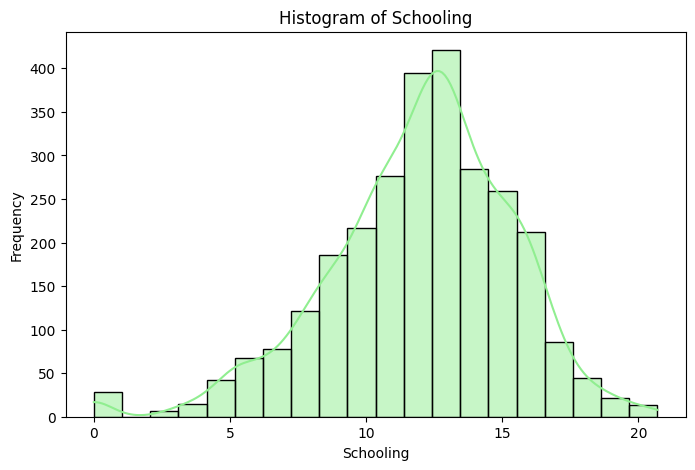

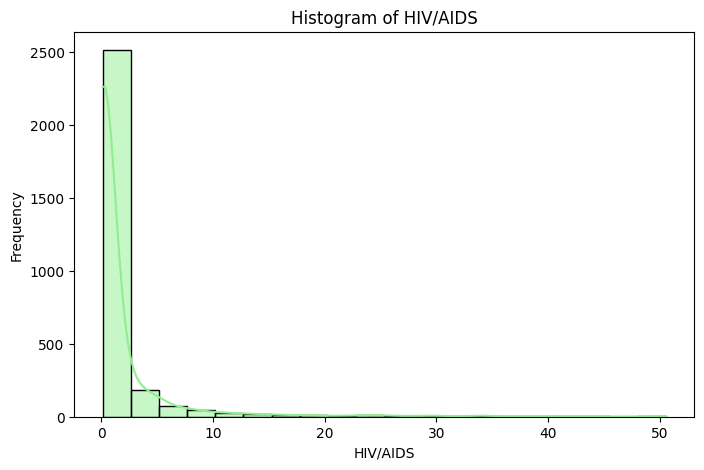

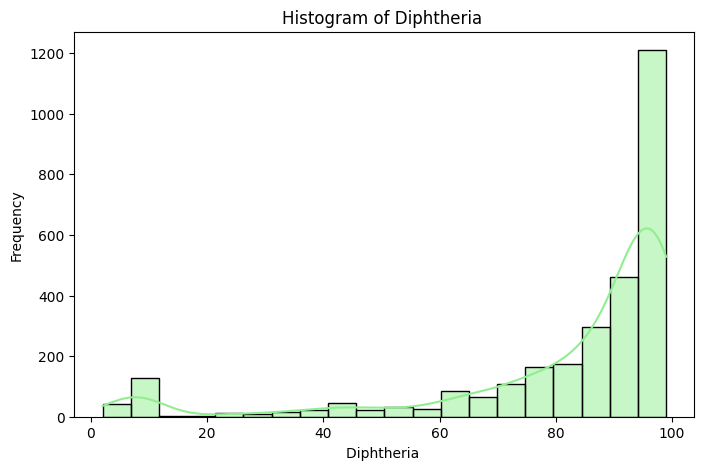

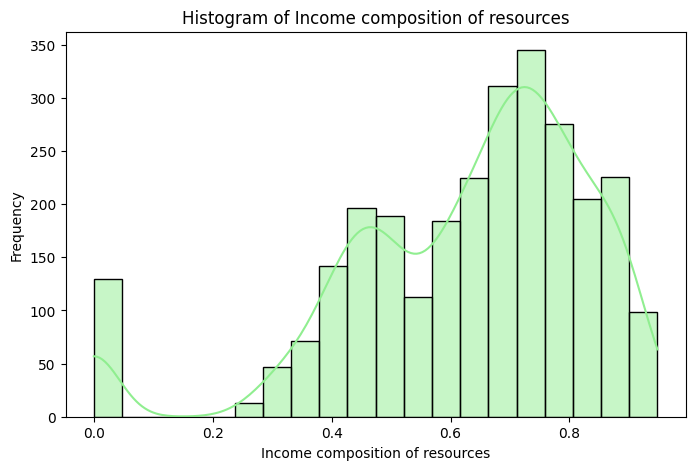

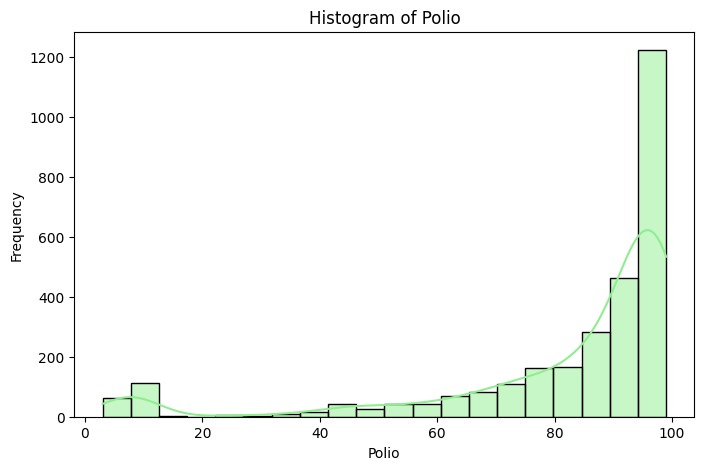

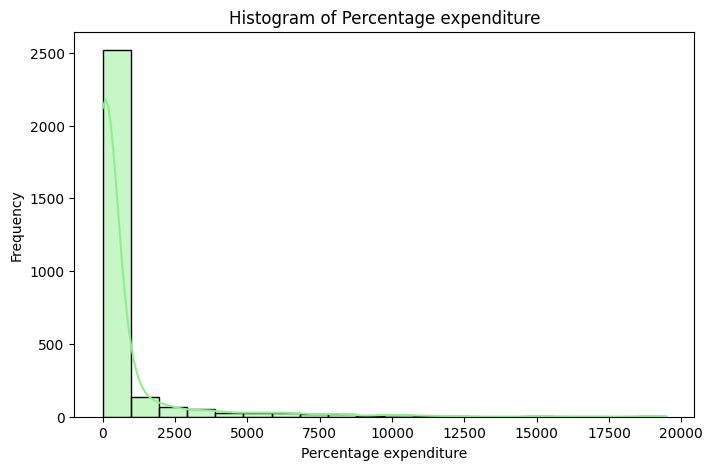

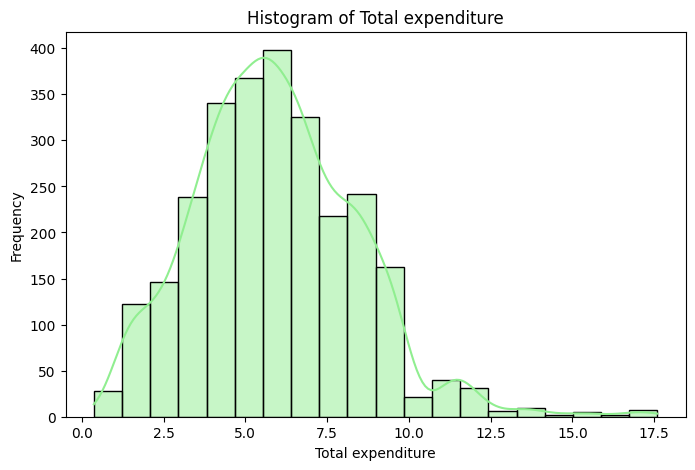

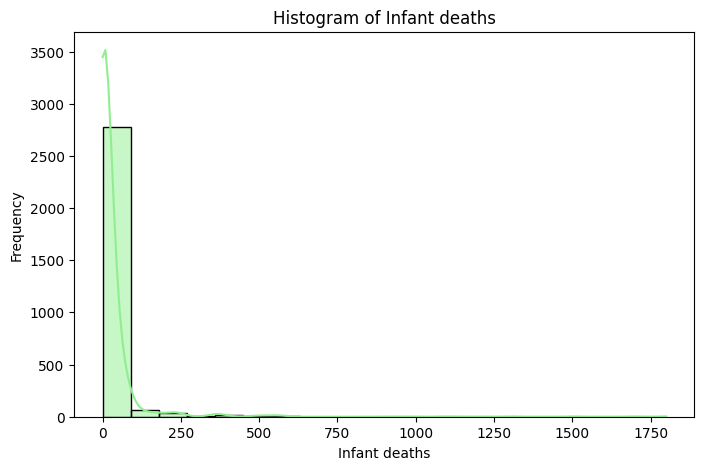

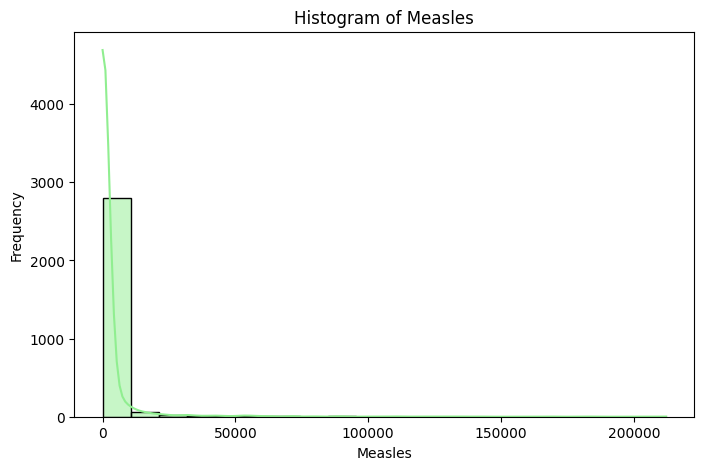

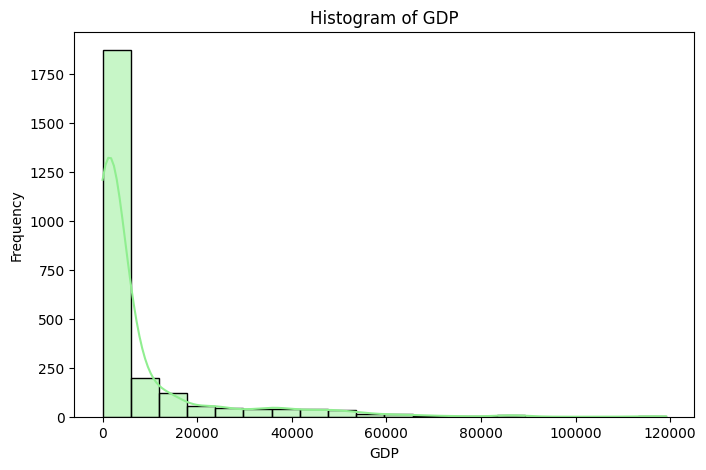

In [114]:
columns_to_plot = ['Schooling', 'HIV/AIDS', 'Diphtheria ', 'Income composition of resources', 'Polio', 'Percentage expenditure','Total expenditure', 'Infant deaths', 'Measles', 'GDP']
for col in columns_to_plot:
    plt.figure(figsize=(8,5))
    sns.histplot(life_data[col], bins=20, kde=True, color='lightgreen')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [115]:
life_data['Schooling'].skew()

np.float64(-0.6024365418785147)

In [116]:
numeric_cols = life_data.select_dtypes(include='number').columns
check_skew = life_data[numeric_cols].skew()
print(check_skew)

Year                              -0.01
Life expectancy (men)             -0.02
Life expectancy(women)            -0.01
Adult Mortality (men)             -0.01
Adult Mortality (women)            0.05
Infant deaths                      9.79
Alcohol                            0.59
Percentage expenditure             4.65
Hepatitis B(men)                   0.02
Hepatitis B(women)                -0.02
Measles                            9.44
BMI                               -0.22
Under-five deaths                  9.50
Polio                             -2.10
Total expenditure                  0.62
Diphtheria                        -2.07
HIV/AIDS                           5.40
GDP                                3.21
Population                        15.92
thinness  1-19 years               1.71
thinness 5-9 years                 1.78
Income composition of resources   -1.14
Schooling                         -0.60
dtype: float64


A perfectly symmetrical distribution, like a normal "bell curve," has zero skewness, meaning the data points are evenly distributed around the center. Real-world data is often skewed, meaning it leans one way or the other due to the presence of a few extreme values (outliers). the direction of the skew indicates the direction of the outliers, and the magnitude of the skew indicates how far those outliers are pulling the average value away from the center of the majority of the data.

In [117]:
life_data.columns = life_data.columns.str.strip()

In [118]:
life_data.head()

,Country,Year,Status,Life expectancy (men),Life expectancy(women),Adult Mortality (men),Adult Mortality (women),Infant deaths,Alcohol,Percentage expenditure,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,70,66,67,65,62,0.01,71.28,...,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59,67,73,85,64,0.01,73.52,...,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,79,51,87,67,66,0.01,73.22,...,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,65,81,63,91,69,0.01,78.18,...,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,76,75,57,72,71,0.01,7.10,...,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [119]:
life_data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy (men)',
       'Life expectancy(women)', 'Adult Mortality (men)',
       'Adult Mortality (women)', 'Infant deaths', 'Alcohol',
       'Percentage expenditure', 'Hepatitis B(men)', 'Hepatitis B(women)',
       'Measles', 'BMI', 'Under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

We did a common form of feature selection by dropping columns that are not significant for our research question. this way we slowly get a cleaner data set with only the usefull information. 

In [120]:
life_data_subset = life_data.drop(['Country', 'Year', 'Life expectancy (men)',
       'Life expectancy(women)', 'BMI', 'Alcohol', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Adult Mortality (men)',
       'Adult Mortality (women)' ], axis=1).copy()

In [121]:
life_data_subset

,Status,Infant deaths,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling
0,Developing,62,71.28,40,40,1154,83,6.00,8.16,65.00,0.10,584.26,0.48,10.10
1,Developing,64,73.52,20,43,492,86,58.00,8.18,62.00,0.10,612.70,0.48,10.00
2,Developing,66,73.22,25,39,430,89,62.00,8.13,64.00,0.10,631.74,0.47,9.90
3,Developing,69,78.18,54,42,2787,93,67.00,8.52,67.00,0.10,669.96,0.46,9.80
4,Developing,71,7.10,48,24,3013,97,68.00,7.87,68.00,0.10,63.54,0.45,9.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Developing,27,0.00,60,37,31,42,67.00,7.13,65.00,33.60,454.37,0.41,9.20
2934,Developing,26,0.00,49,73,998,41,7.00,6.52,68.00,36.70,453.35,0.42,9.50
2935,Developing,25,0.00,37,48,304,40,73.00,6.53,71.00,39.80,57.35,0.43,10.00
2936,Developing,25,0.00,60,38,529,39,76.00,6.16,75.00,42.10,548.59,0.43,9.80


When looking at the shape we can see that we significantly reduced the size of the data set. this will be a benefit for us when we start working with ML models.

In [122]:
life_data_subset.shape

(2938, 14)

In [124]:
life_data_subset.isnull().sum()

Status                               0
Infant deaths                        0
Percentage expenditure               0
Hepatitis B(men)                     0
Hepatitis B(women)                   0
Measles                              0
Under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Income composition of resources    167
Schooling                          163
dtype: int64

In [125]:
life_data_subset.loc[life_data_subset.duplicated()]

,Status,Infant deaths,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling


We started to analyse the relationship of certain variables and along side a correlation heatmap. 

In [135]:
df_corr = life_data_subset[['Infant deaths', 'Percentage expenditure', 'Hepatitis B(men)',
       'Hepatitis B(women)', 'Measles', 'Under-five deaths', 'Polio',
       'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP',
       'Income composition of resources', 'Schooling']].corr()
df_corr

,Infant deaths,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling
Infant deaths,1.00,-0.09,-0.03,-0.04,0.50,1.00,-0.17,-0.13,-0.18,0.03,-0.11,-0.15,-0.19
Percentage expenditure,-0.09,1.00,-0.01,-0.01,-0.06,-0.09,0.15,0.17,0.14,-0.10,0.90,0.38,0.39
Hepatitis B(men),-0.03,-0.01,1.00,0.01,-0.00,-0.03,0.00,0.01,0.00,0.01,-0.01,0.01,0.01
Hepatitis B(women),-0.04,-0.01,0.01,1.00,-0.02,-0.04,0.00,0.02,0.00,-0.00,-0.01,-0.01,-0.01
Measles,0.50,-0.06,-0.00,-0.02,1.00,0.51,-0.14,-0.11,-0.14,0.03,-0.08,-0.13,-0.14
Under-five deaths,1.00,-0.09,-0.03,-0.04,0.51,1.00,-0.19,-0.13,-0.20,0.04,-0.11,-0.16,-0.21
Polio,-0.17,0.15,0.00,0.00,-0.14,-0.19,1.00,0.14,0.67,-0.16,0.21,0.38,0.42
Total expenditure,-0.13,0.17,0.01,0.02,-0.11,-0.13,0.14,1.00,0.15,-0.00,0.14,0.17,0.25
Diphtheria,-0.18,0.14,0.00,0.00,-0.14,-0.20,0.67,0.15,1.00,-0.16,0.20,0.40,0.43
HIV/AIDS,0.03,-0.10,0.01,-0.00,0.03,0.04,-0.16,-0.00,-0.16,1.00,-0.14,-0.25,-0.22


This is the correlations in a table fromat. But we felt that these were beter to be understood in a heatmap

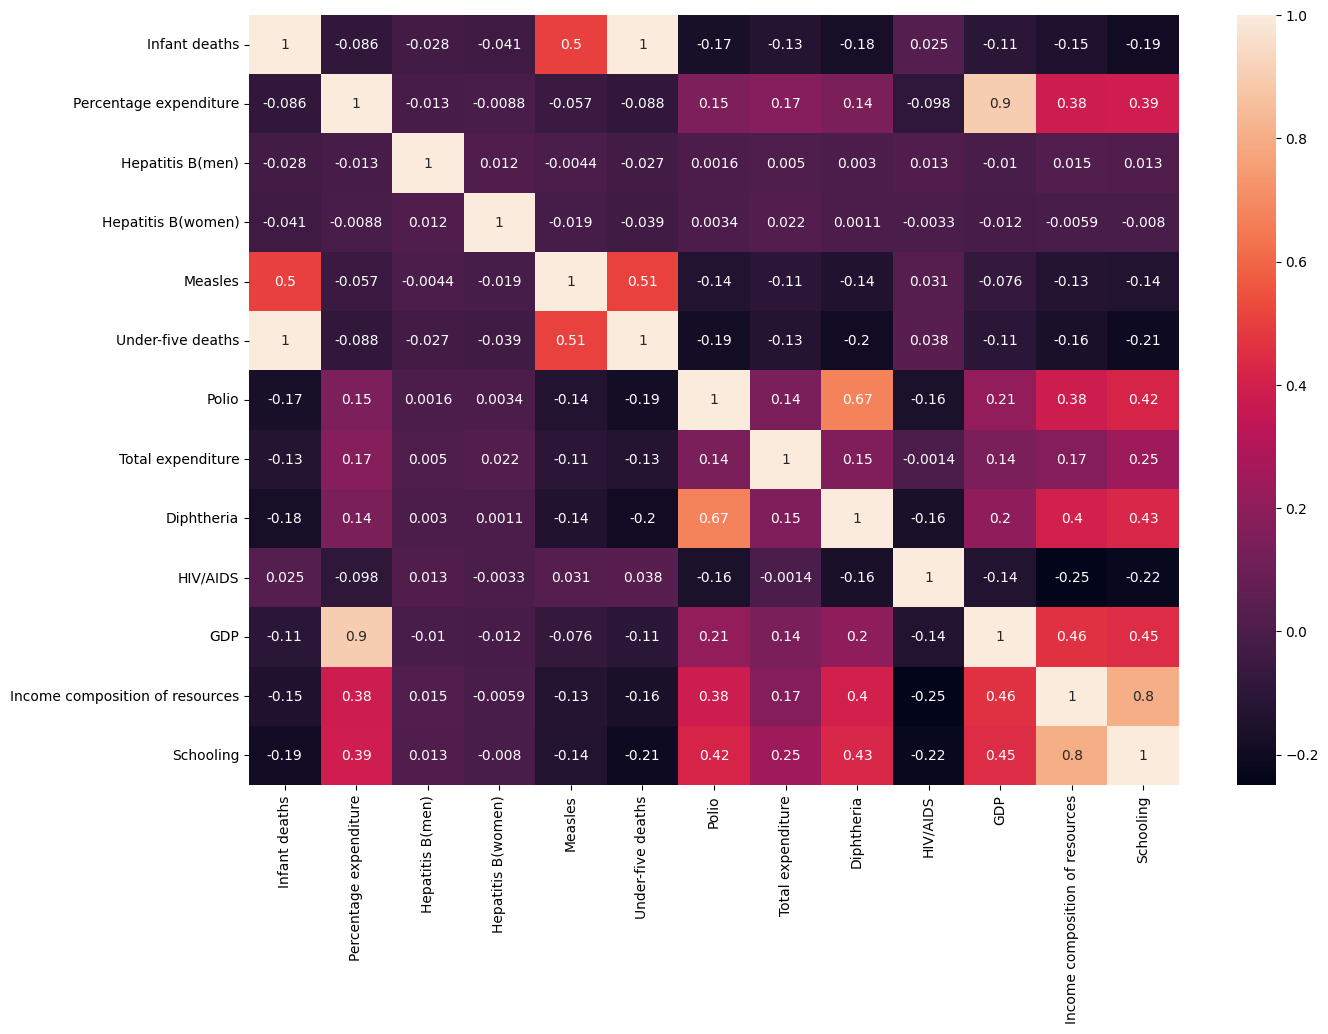

In [136]:
plt.figure(figsize=(15,10))
sns.heatmap(df_corr, annot=True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

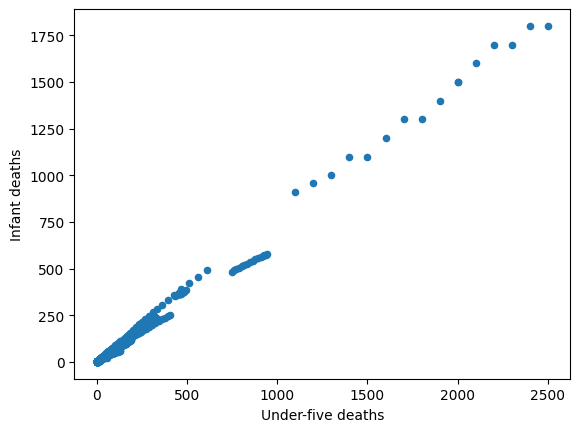

In [129]:
life_data_subset.plot(kind='scatter', x='Under-five deaths', y='Infant deaths')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

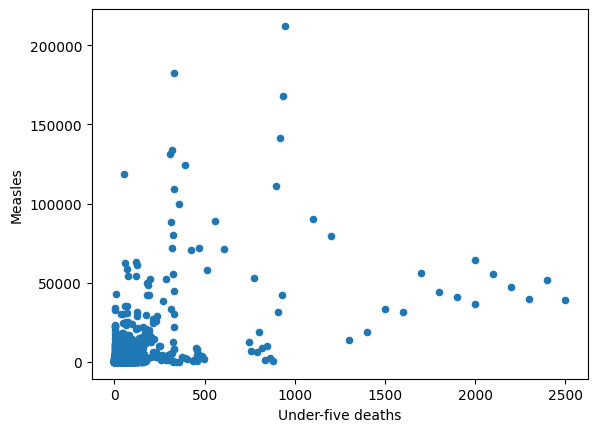

In [ ]:
life_data_subset.plot(kind='scatter', x='Under-five deaths', y='Measles')
plt.show

Relationship Between Variables
- Infant deaths vs. Under-five deaths: Highly correlated; since under-five deaths include infant deaths, infant deaths will be removed to avoid multicollinearity.
- Hepatitis B: Coverage is similar for both genders; the average of the two will be used.

Correlation Heatmap
- Hepatitis shows weak correlation with other variables.
- Income composition of resources is moderately to highly correlated with schooling, GDP, Diphtheria, Polio, and percentage expenditure.
- Schooling is moderately correlated with Polio, Diphtheria, GDP, and percentage expenditure, and highly correlated with income composition.
- Under-five deaths are moderately correlated only with measles; other correlations are weak.

Multicollinearity
- Remove infant deaths due to perfect correlation with under-five deaths.
- Remove either percentage expenditure or GDP due to 0.9 correlation.
- Percentage expenditure is more directly related to the research question, while GDP reflects overall economic capacity.
- We will create a combined variable to retain information from both GDP and percentage expenditure for interpretation


The following lines of code will be imputation of some featues, combining and overall applying the transformation that was identified previously.

In [138]:
life_data_subset['GDP'].value_counts()

GDP
584.26     1
354.82     1
359.00     1
43.65      1
416.15     1
          ..
4274.38    1
4142.87    1
3725.63    1
2964.48    1
547.36     1
Name: count, Length: 2490, dtype: int64

In [140]:
life_data_subset.isnull().sum()

Status                               0
Infant deaths                        0
Percentage expenditure               0
Hepatitis B(men)                     0
Hepatitis B(women)                   0
Measles                              0
Under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Income composition of resources    167
Schooling                          163
dtype: int64

In [ ]:
life_data_subset['Percentage expenditure'].value_counts

<bound method IndexOpsMixin.value_counts of 0      71.28
1      73.52
2      73.22
3      78.18
4       7.10
        ... 
2933    0.00
2934    0.00
2935    0.00
2936    0.00
2937    0.00
Name: Percentage expenditure, Length: 2938, dtype: float64>

In [142]:
life_data_subset['Percentage expenditure'] = life_data_subset['Percentage expenditure'].replace(0, np.nan)

In [1]:
life_data_subset['GDP'] = life_data_subset['GDP'].replace(0, np.nan)

NameError: name 'life_data_subset' is not defined

In [ ]:
life_data_subset['GDP'].isna().sum()

np.int64(448)

In [145]:
life_data_subset['Percentage expenditure'].isna().sum()

np.int64(611)

In [146]:
median_cols = ['GDP', 'Polio', 'Diphtheria', 'HIV/AIDS', 
               'Income composition of resources', 'Percentage expenditure']
mean_cols = ['Schooling', 'Total expenditure']

for col in median_cols:
    life_data_subset[col] = life_data_subset[col].fillna(life_data_subset[col].median())

for col in mean_cols:
    life_data_subset[col] = life_data_subset[col].fillna(life_data_subset[col].mean())



In [ ]:
life_data_subset[mean_cols].isna().sum()

Schooling            0
Total expenditure    0
dtype: int64

In [ ]:
life_data_subset[median_cols].isna().sum()

GDP                                0
Polio                              0
Diphtheria                         0
HIV/AIDS                           0
Income composition of resources    0
Percentage expenditure             0
dtype: int64

In [149]:
life_data_subset['Status'] = life_data_subset['Status'].map({'Developing': 0, 'Developed': 1})

In [ ]:
life_data_subset.head()

,Status,Infant deaths,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling
0,0,62,71.28,40,40,1154,83,6.00,8.16,65.00,0.10,584.26,0.48,10.10
1,0,64,73.52,20,43,492,86,58.00,8.18,62.00,0.10,612.70,0.48,10.00
2,0,66,73.22,25,39,430,89,62.00,8.13,64.00,0.10,631.74,0.47,9.90
3,0,69,78.18,54,42,2787,93,67.00,8.52,67.00,0.10,669.96,0.46,9.80
4,0,71,7.10,48,24,3013,97,68.00,7.87,68.00,0.10,63.54,0.45,9.50


In [151]:
life_data_subset['Hepatitis_B_avg'] = (life_data_subset['Hepatitis B(men)'] + 
                                       life_data_subset['Hepatitis B(women)']) / 2


In [152]:
life_data_subset = life_data_subset.drop(['Hepatitis B(men)', 'Hepatitis B(women)'], axis=1)

In [ ]:
#Checking to see if the computation worked
life_data_subset[['Hepatitis_B_avg']].head()

,Hepatitis_B_avg
0,40.00
1,31.50
2,32.00
3,48.00
4,36.00


In [154]:
life_data_subset.head()

,Status,Infant deaths,Percentage expenditure,Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Income composition of resources,Schooling,Hepatitis_B_avg
0,0,62,71.28,1154,83,6.00,8.16,65.00,0.10,584.26,0.48,10.10,40.00
1,0,64,73.52,492,86,58.00,8.18,62.00,0.10,612.70,0.48,10.00,31.50
2,0,66,73.22,430,89,62.00,8.13,64.00,0.10,631.74,0.47,9.90,32.00
3,0,69,78.18,2787,93,67.00,8.52,67.00,0.10,669.96,0.46,9.80,48.00
4,0,71,7.10,3013,97,68.00,7.87,68.00,0.10,63.54,0.45,9.50,36.00


In [155]:
#Dropping infant deaths as was previously stated
life_data_subset = life_data_subset.drop(['Infant deaths'], axis=1)

In [159]:
numeric_cols_b = life_data_subset.select_dtypes(include='number').columns
check_skew = life_data_subset[numeric_cols_b].skew()
print(check_skew)

Status                             1.72
Percentage expenditure             4.69
Measles                            9.44
Under-five deaths                  9.50
Polio                             -2.11
Total expenditure                  0.64
Diphtheria                        -2.08
HIV/AIDS                           5.40
GDP                                3.54
Income composition of resources   -1.21
Schooling                         -0.62
Hepatitis_B_avg                    0.01
dtype: float64


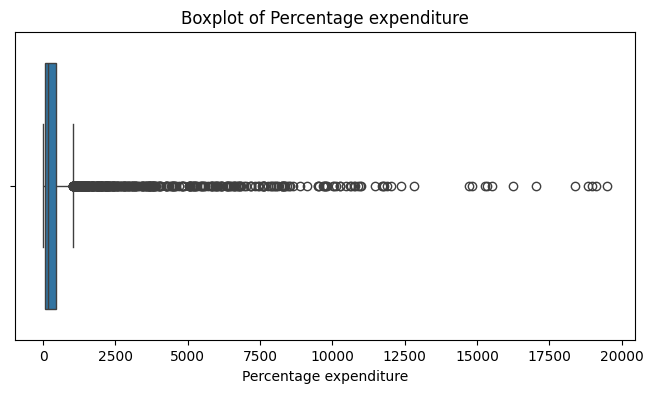

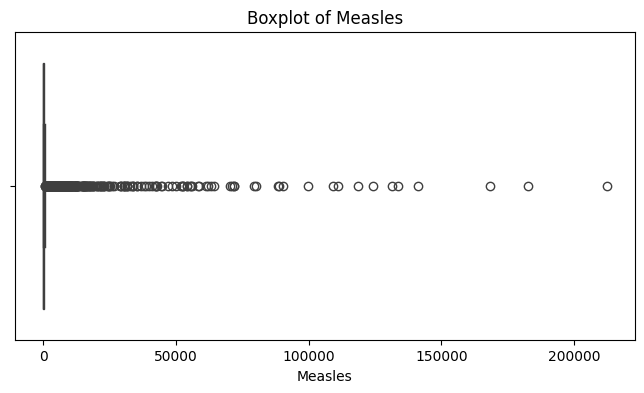

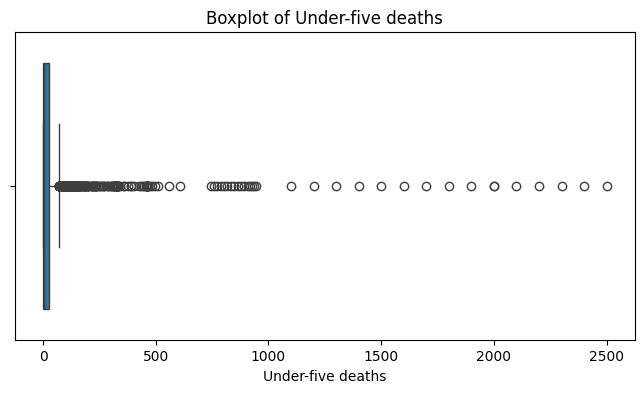

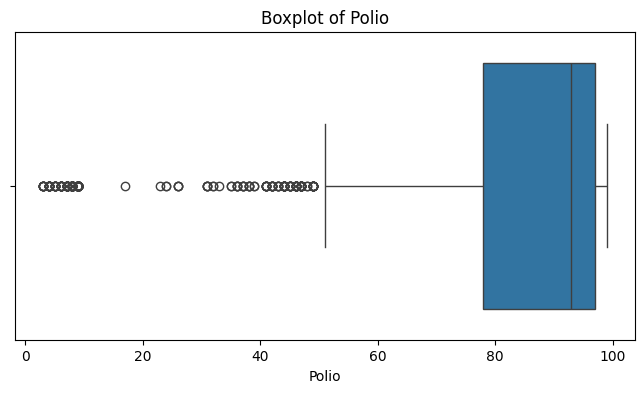

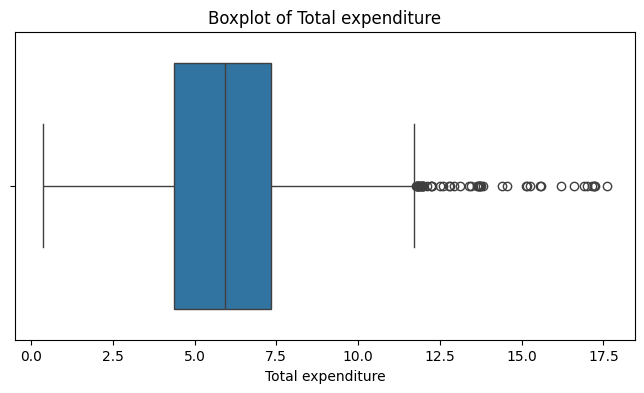

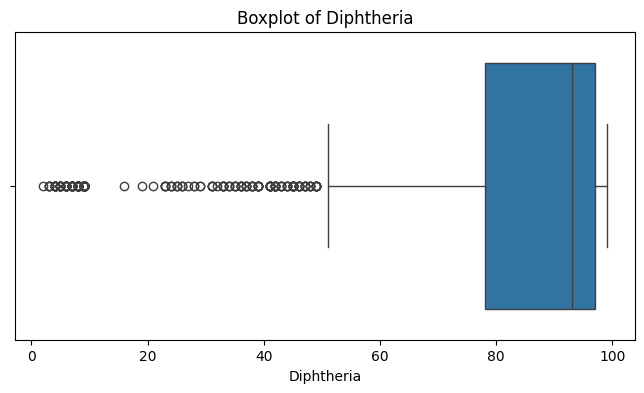

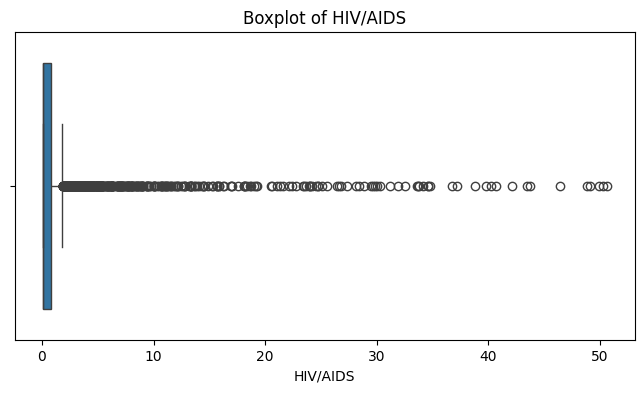

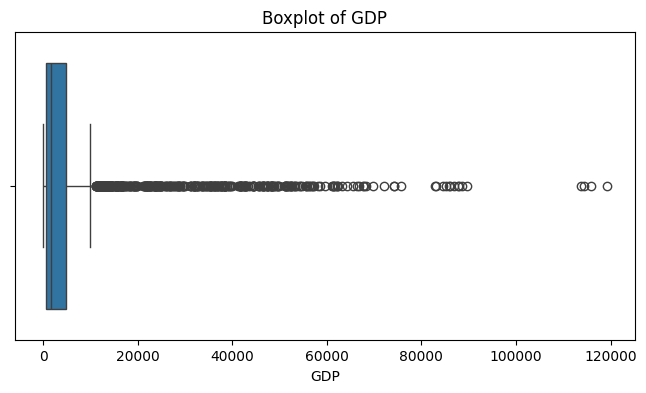

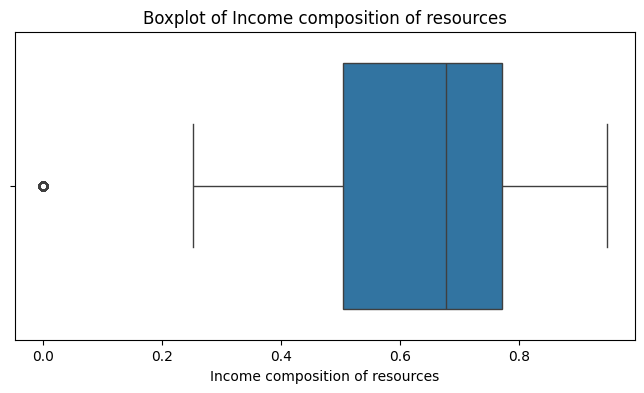

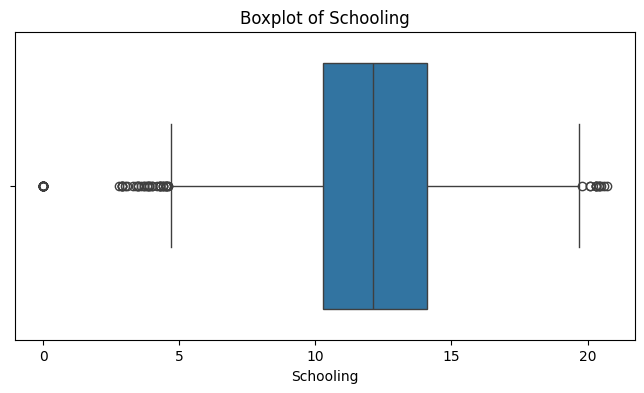

In [160]:
#checking for outliers as some models are sensitive to outliers. This will aid in selecting the appropriate models to avoid biased predications

skewed_cols = ['Percentage expenditure', 'Measles', 'Under-five deaths',
       'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP',
       'Income composition of resources', 'Schooling',]

for col in skewed_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=life_data_subset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
#Combining GDP with percentage expenditure.
life_data_subset['Health_spending_per_capita'] = (
    life_data_subset['GDP'] * (life_data_subset['Percentage expenditure'] / 100))


In [ ]:
df_corr_c = life_data_subset[['Percentage expenditure', 'Measles', 'Under-five deaths',
       'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP',
       'Income composition of resources', 'Schooling', 'Hepatitis_B_avg',
       'Health_spending_per_capita']].corr()


<function matplotlib.pyplot.show(close=None, block=None)>

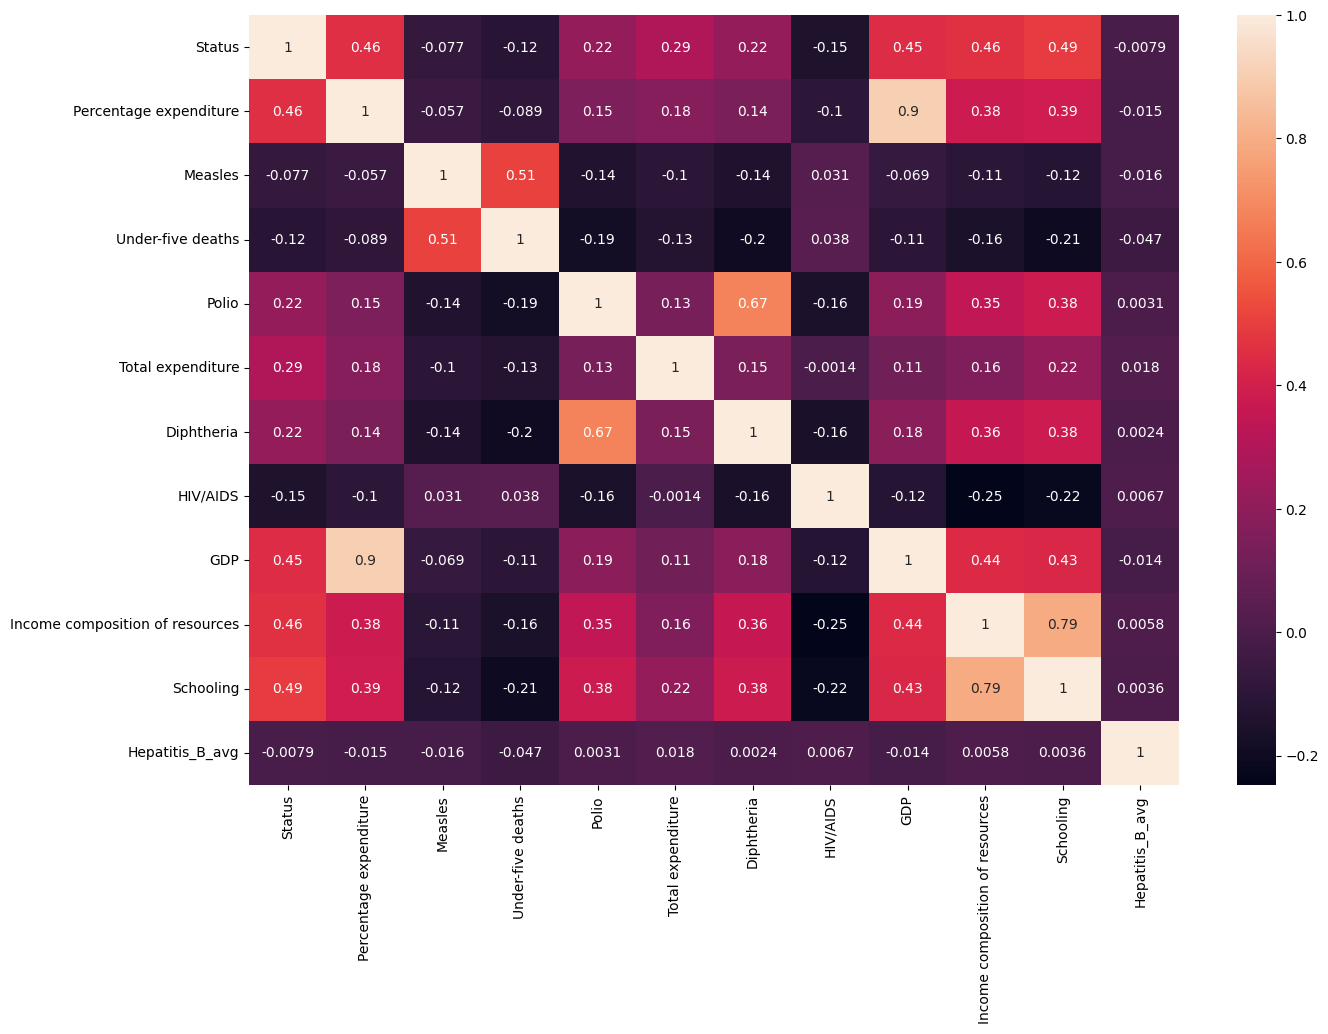

In [164]:
plt.figure(figsize=(15,10))
sns.heatmap(df_corr, annot=True)
plt.show

In [165]:
life_data_subset = life_data_subset.drop(['GDP'], axis=1)


After performing imputation, a second correlation heatmap was generated to examine whether the imputation process altered the relationships between variables.

After taking the average of Hepatitis B for both gender, the variable still did not show increased significance. As shown in the correlation heatmap, its relationship with the target variable remained weak, and it showed minimal association with the other predictors as well. Although the literature presents mixed findings regarding under-five mortality and vaccination coverage as Hepatitis B was already a weak candidate. We retained it initially to see whether it might reveal any predictive value within our dataset. However, this was not the case. Given its consistently low relevance, we are confident in removing this variable without risk of losing meaningful information.

In [169]:
life_data_subset.drop('Hepatitis_B_avg', axis=1, inplace=True)

In [170]:
life_data_subset.head()

,Status,Percentage expenditure,Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,Income composition of resources,Schooling,Health_spending_per_capita
0,0,71.28,1154,83,6.00,8.16,65.00,0.10,0.48,10.10,416.46
1,0,73.52,492,86,58.00,8.18,62.00,0.10,0.48,10.00,450.48
2,0,73.22,430,89,62.00,8.13,64.00,0.10,0.47,9.90,462.56
3,0,78.18,2787,93,67.00,8.52,67.00,0.10,0.46,9.80,523.80
4,0,7.10,3013,97,68.00,7.87,68.00,0.10,0.45,9.50,4.51


In [171]:
life_data_training = life_data_subset.copy()

In [172]:
life_data_training.head()

,Status,Percentage expenditure,Measles,Under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,Income composition of resources,Schooling,Health_spending_per_capita
0,0,71.28,1154,83,6.00,8.16,65.00,0.10,0.48,10.10,416.46
1,0,73.52,492,86,58.00,8.18,62.00,0.10,0.48,10.00,450.48
2,0,73.22,430,89,62.00,8.13,64.00,0.10,0.47,9.90,462.56
3,0,78.18,2787,93,67.00,8.52,67.00,0.10,0.46,9.80,523.80
4,0,7.10,3013,97,68.00,7.87,68.00,0.10,0.45,9.50,4.51


In [188]:
# Option 1: correlation matrix (all numeric cols) using Spearman
spearman_corr = life_data_subset.corr(method='spearman', numeric_only=True)
print("Spearman correlation matrix:")
print(spearman_corr)


Spearman correlation matrix:
                                 Status  Percentage expenditure  Measles  \
Status                             1.00                    0.39    -0.04   
Percentage expenditure             0.39                    1.00    -0.22   
Measles                           -0.04                   -0.22     1.00   
Under-five deaths                 -0.39                   -0.45     0.57   
Polio                              0.25                    0.32    -0.27   
Total expenditure                  0.31                    0.23    -0.18   
Diphtheria                         0.27                    0.33    -0.26   
HIV/AIDS                          -0.36                   -0.39     0.20   
Income composition of resources    0.56                    0.62    -0.23   
Schooling                          0.52                    0.60    -0.28   
Health_spending_per_capita         0.40                    0.97    -0.22   

                                 Under-five deaths  Polio 

The Spearman correlation results show several important relationships relevant to predicting under-five deaths. Vaccination indicators demonstrate meaningful associations with child mortality:
- Polio immunization and Diphtheria immunization both show moderate negative correlations with under-five deaths (around –0.43).

Indicating that higher vaccine coverage tends to coincide with lower mortality.
- In contrast, Measles shows a moderate positive correlation with under-five deaths (+0.57).

Suggesting that higher measles prevalence is associated with worse child outcomes.

Socio-economic variables also play a substantial role.
- Schooling exhibits one of the strongest correlations with under-five deaths (–0.60)
- Followed closely by income composition of resources (–0.57).

Highlighting that lower education levels and poorer economic conditions are linked to higher mortality.

- Health spending per capita is moderately associated as well (–0.40).
Reinforcing the impact of overall health system investment on child survival.

Additionally, vaccination variables are strongly correlated with one another for example, Polio and Diphtheria show a high positive correlation (0.92) suggesting that countries with strong healthcare infrastructures tend to perform consistently across multiple immunization programs. 

Overall, these relationships support the relevance of vaccination coverage, socio-economic status, and health investment as key predictors for under-five deaths, justifying their inclusion in the machine learning models.

## Part 3: Validation & Evaluation - Predictive Modeling

In [190]:
X = life_data_training.drop('Under-five deaths', axis=1)
y = life_data_training['Under-five deaths']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train-test splitting is a fundamental technique in machine learning used to evaluate a model's performance on unseen data. It involves partitioning a dataset into two distinct, non-overlapping subsets: a training set and a testing set.

- First we separate the dataset into `Features (X)` , all collumns except the Under-five deaths column and the `Target Variable (y)` which is the Under-five deaht column itself, so the value we want to predict. 
- Secondly we use the `train_test_split` function to divide these features and target variables into separate training 80% and test 20% sets. This ensures that the moedl is built on the training data (`X_train`, `y_train`) and evaluated on the unseen data (`X_test`, `y_test`). 
- Lastly, the `random_state = 42` ensures the split is consistent and reproducible every time the code runs.

In [191]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is the process of transforming the range of your independent variables (features) so they all share a comparable scale.

The goal is to bring all numerical features into a similar magnitude or distribution to prevent one feature from dominating the others simply because its values are numerically larger.


In [203]:
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

LinearRegression()

Here we take our scaled traning and test data and make it ready for a polynomial regression model. 
- First, we create a `PolynomialFeatures` object with `degree=2`, which means it will add squared terms and interaction terms between features.
- Then we transforms the training and test sets so they include these new polynomial features.
- After that, it creates a linear regression model and trains it on the transformed training data, so the model can learn relationships not just from the original features but also from their squares and interactions.

Right now we are starting with degree 2, but later we will check which degree works best by testing different degrees and comparing their performance.

In [176]:
rf = RandomForestRegressor(n_estimators=300,random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
param_grid = {'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']}

rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,  
    cv=5,
    n_jobs=-1,
    random_state=42)

rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Best parameters:", rf_random.best_params_)

Best parameters: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None}


In [213]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Here we use the `RandomForestRegressor`.
- First, we create a Random Forest model with 300 trees and train it on the training data.
- Then, we define a grid of hyperparameters, like number of trees, maximum depth, and number of features to consider at each split, and use `RandomizedSearchCV` to automatically test different combinations with 5-fold cross-validation.
- After fitting, we get the best-performing model and use it to make predictions on the test set, also printing the best hyperparameters.
- Finally, we create a new Random Forest using those tuned parameters, train it on the training data again, and make predictions, which ensures we are using the optimized model for the most accurate results.


In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_cv.alpha_)
print("Training score:", ridge_cv.score(X_train, y_train))
print("Test score:", ridge_cv.score(X_test, y_test))


Best Ridge alpha: 100.0
Training score: 0.2863382563929211
Test score: 0.28794110334011547


This code sets up Ridge regression with cross-validation to find the best regularization strength.
- First, we define a range of `alpha` values to try, which control how much the model shrinks the coefficients to prevent overfitting.
- hen, `RidgeCV` tests all these alphas using 5-fold cross-validation on the training data and automatically picks the one that works best.

In [ ]:
lasso_cv = LassoCV(cv=5, n_alphas=100, random_state=42)
lasso_cv.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_cv.alpha_)
print("Training score:", lasso_cv.score(X_train, y_train))
print("Test score:", lasso_cv.score(X_test, y_test))

Best Lasso alpha: 47459.469736098246
Training score: 0.2537912142051084
Test score: 0.2591596299964428


This code runs Lasso regression with 5-fold cross-validation (`cv=5`) to find the best alpha from 100 options (`n_alphas=100`).

In [ ]:
print(ridge_cv.alpha_)
print(lasso_cv.alpha_)

100.0
47459.469736098246


In [ ]:
y_pred_lin = lin_reg.predict(X_test_scaled)

y_pred_ridge = ridge_cv.predict(X_test_scaled)

y_pred_lasso = lasso_cv.predict(X_test_scaled)

y_pred_rf = rf.predict(X_test)

C:\Users\suden\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RidgeCV was fitted with feature names
  warnings.warn(
C:\Users\suden\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


In [222]:
results = {"Model": ["Polynomial", "RidgeCV", "LassoCV", "Random Forest"],"RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    "R2 Score": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf)]}

results_df = pd.DataFrame(results)
print(results_df)


           Model   RMSE  R2 Score
0     Polynomial 157.94      0.29
1        RidgeCV 216.46     -0.34
2        LassoCV 188.66     -0.02
3  Random Forest  64.49      0.88


!Comment!
- Even though the professor suggested trying polynomial regression, in our dataset it didn’t improve performance because the target variable’s relationship with the features is mostly linear or simple enough for a standard linear model. That’s why `RMSE` and `R²` didn’t change when we added polynomial features or increased the degree.
- In our presentation, the Random Forest model was already the best-performing model, but after reviewing the code we tuned it again using `RandomizedSearchCV`. This produced a new set of hyperparameters, which further improved its performance lowering the `RMSE` and bringing the `R²` closer to 1. The tuned Random Forest now provides even more accurate predictions of under-five mortality rates, highlighting the value of hyperparameter optimization for enhancing model performance.

Analysis on our output
1. Polynomial Regression: RMSE is 157.94 and R² = 0.29. The model explains only about 29% of the variance in the data, so it captures some trends but misses a lot of the variation. Adding polynomial features didn’t improve performance much, indicating the linear model couldn’t capture the complex relationships in the data.
2. RidgeCV and LassoCV: Both performed poorly, with negative R² for RidgeCV (-0.34) and near zero for LassoCV (-0.02). This shows that regularized linear models didn’t fit the data well; in fact, RidgeCV is worse than predicting the mean. This confirms that simple linear relationships aren’t sufficient for the dataset.
3. Random Forest: RMSE = 64.49 and R² = 0.88. This is by far the best performing model. It explains 88% of the variance and has the lowest prediction error. Random Forest works well because it can capture nonlinear patterns and interactions between features, which are likely present in factors affecting under-five mortality.

In [ ]:
features = X_train.columns
importances = rf.feature_importances_
feat_importance_df = pd.DataFrame({'Feature': features,'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)
print(feat_importance_df)


                           Feature  Importance
2                          Measles        0.43
4                Total expenditure        0.09
6                         HIV/AIDS        0.09
7  Income composition of resources        0.09
3                            Polio        0.07
5                       Diphtheria        0.07
8                        Schooling        0.06
9       Health_spending_per_capita        0.05
1           Percentage expenditure        0.05
0                           Status        0.00


C:\Users\suden\AppData\Local\Temp\ipykernel_34828\2692076697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')


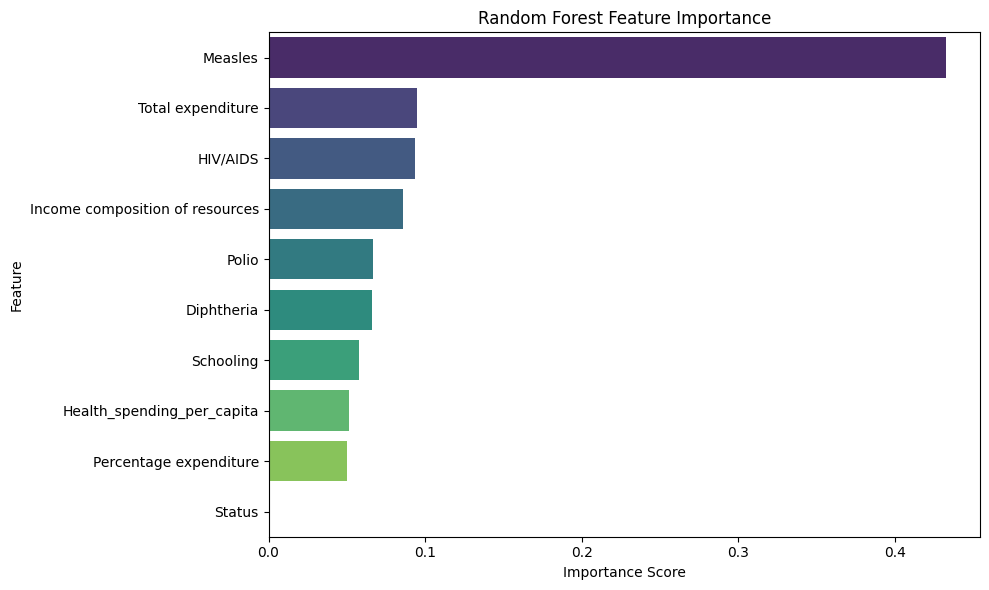

In [217]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

From the feature importance table and graph, we can see that Measles vaccination coverage is by far the most important factor for predicting under-five mortality, with an importance of 0.43.

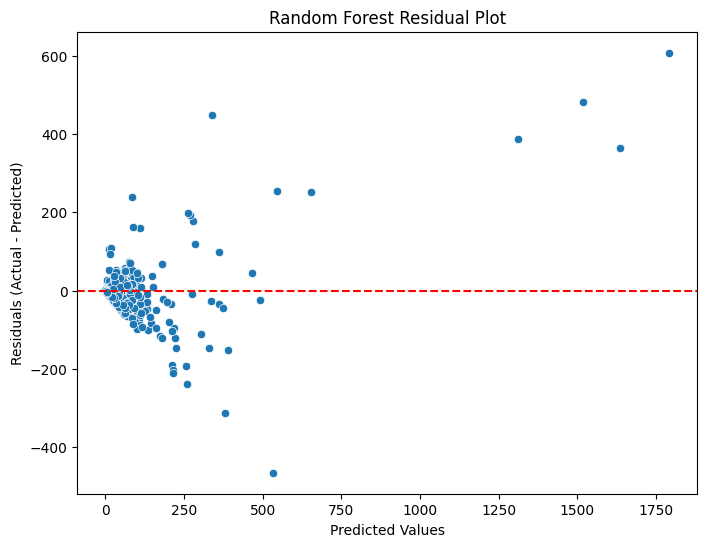

In [ ]:
y_pred_rf = rf.predict(X_test)
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Random Forest Residual Plot')
plt.show()

The residual plot shows that most predictions are close to the actual values, with residuals scattered around zero. There’s a bit more spread for higher mortality rates, but overall the Random Forest captures the main patterns well without major bias.

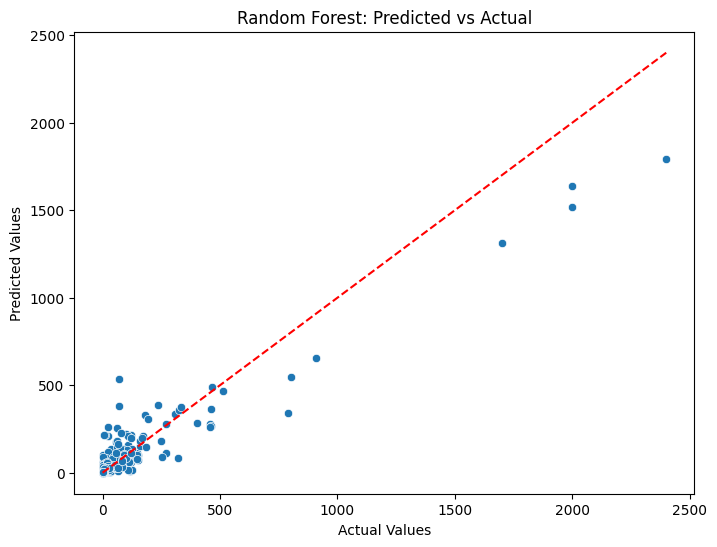

In [219]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: Predicted vs Actual')
plt.show()


The Predicted vs Actual plot shows that the Random Forest model performs fairly well for lower under-five death counts, where most points fall close to the ideal prediction line. However, as the actual number of deaths increases, the model struggles and consistently underestimates the values. This suggests that the model captures general trends but is less reliable for countries or regions with very high under-five mortality. Overall, the results indicate that while the model can support vaccination distribution planning, it may need further tuning or more data to improve accuracy for high-risk areas

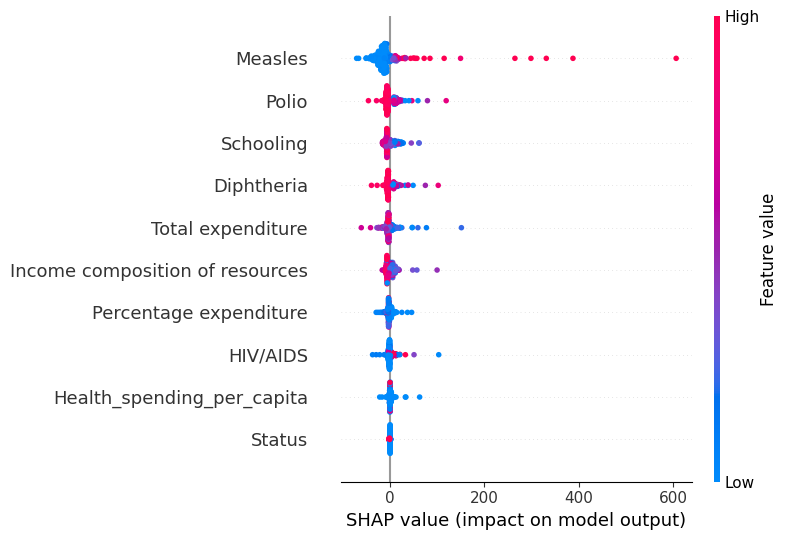

In [220]:
explainer = shap.TreeExplainer(rf)
sample_X = X_train.sample(300, random_state=42)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X)

The SHAP summary plot shows which factors most influence our model when predicting under-five deaths. Measles and Polio vaccination rates appear to have the strongest impact, where low vaccination levels (blue points) tend to increase predicted child deaths, while higher rates reduce them. Schooling and health-spending variables also contribute, meaning countries with better education and higher healthcare investment generally show lower predicted mortality. Overall, the plot highlights that improving vaccination coverage and strengthening health systems are key factors in reducing under-five deaths and can help guide better vaccine distribution strategies.

## Part 4: Conclusion

This project set out to develop a machine learning framework capable of predicting under-five mortality to support vaccine allocation and strategic decision-making for global health organisations. After extensive data cleaning, feature engineering, and modelling, several key findings emerged.

First, although the dataset contained rich health and socioeconomic indicators, the overall correlations with under-five mortality were weak, even after preprocessing. This suggests that the dataset may not optimally capture the true drivers of child mortality, which often involve unmeasured factors such as conflict, healthcare infrastructure quality, and specific disease outbreaks. Nevertheless, the Random Forest model achieved strong predictive performance (R² ≈ 0.88), outperforming the rest by a wide margin, indicating that non-linear patterns in the data were significant and better captured by ensemble methods.

From a business perspective, the project demonstrated how a data-driven approach can improve early identification of high-risk countries, potentially enabling more strategic vaccine distribution and stronger justification for donor funding. Feature importance analysis further illustrated which national indicators are most influential for predicting under-five deaths, offering an interpretable tool for organisations such as UNICEF, WHO, and Gavi.

Despite these contributions, several limitations must be acknowledged. The dataset’s weak correlation structure suggests it may not fully represent the causal factors behind child mortality. Model generalisability is constrained by the fact that national-level data may hide within-country disparities that are critical for health planning.

These limitations open clear directions for future work, which is both feasible and highly impactful. Future improvements include integrating richer datasets (e.g., conflict indices, healthcare workforce metrics), applying advanced ML models such as XGBoost or LightGBM, and performing forecasting to predict changing mortality trends over time. Additionally, developing explainability tools (e.g., SHAP values) would allow decision-makers to understand model reasoning more transparently, interability.

Overall, this project demonstrates how machine learning can meaningfully support global health policy by transforming complex health data into actionable insights, while also making a space for more sophisticated and impactful modelling approaches.